# Lab Assignment 4 — Logistic Regression
## Breast Cancer Wisconsin (Diagnostic) Dataset

**Course:** CSET343 — AI in Healthcare | **Objective:** Preprocess data, train and evaluate a logistic regression model for binary classification, and interpret results in a medical diagnosis context.

## Task 1: Data Acquisition and Exploration

### 1.1 Load the dataset
Acquired via scikit-learn's built-in loader (same data as the UCI/Kaggle "Breast Cancer Wisconsin (Diagnostic)" dataset — 569 samples, 30 numeric features computed from digitized images of fine needle aspirate (FNA) of breast masses, target: malignant vs. benign).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)
np.random.seed(42)

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign (sklearn's encoding)
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### 1.2 Summary Statistics

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 1.3 Missing Values, Duplicates, Outliers

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values

Duplicate rows: 0


In [4]:
# Outlier detection via IQR method across all 30 numeric features
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lo) | (series > hi)).sum()

outlier_counts = df[data.feature_names].apply(iqr_outlier_count).sort_values(ascending=False)
print("Top 10 features by IQR-outlier count:")
print(outlier_counts.head(10))
print(f"\nTotal outlier flags across all features: {outlier_counts.sum()}")

Top 10 features by IQR-outlier count:
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
dtype: int64

Total outlier flags across all features: 608


**Handling:** No missing values or duplicate rows were found — no imputation needed. Outliers exist in several features (expected in oncology measurements — some tumors are genuinely much larger/more irregular than others) and are **not removed**, since extreme values often carry real diagnostic signal (e.g., very large mean radius is itself predictive of malignancy). Instead, standardization (Task 2) reduces their influence on distance/scale-sensitive optimization without discarding genuine cases.

### 1.4 Visualizations

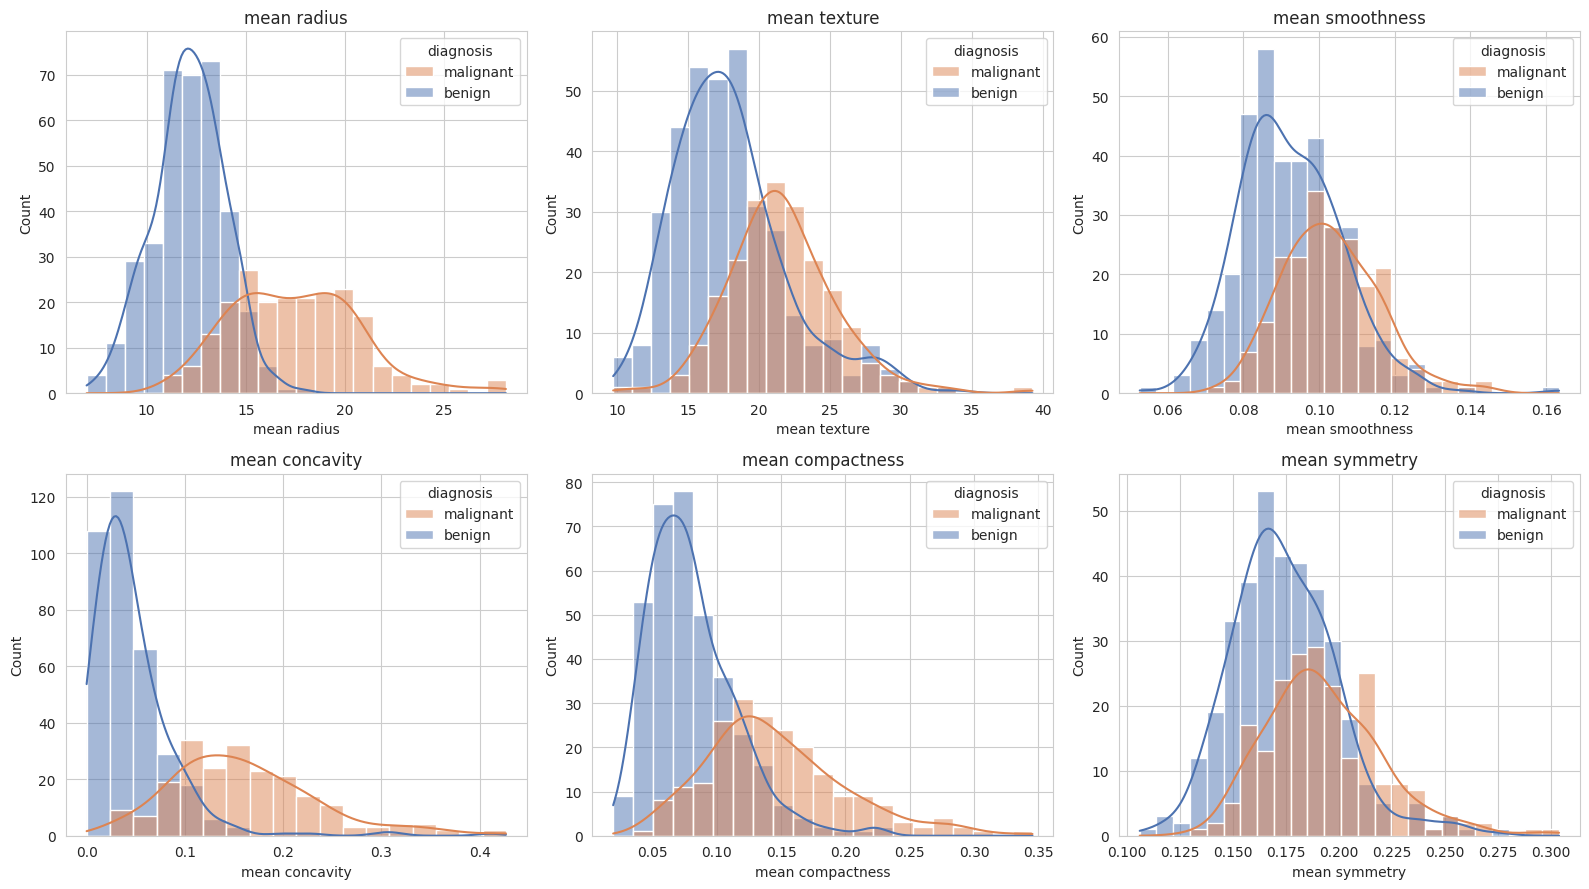

In [5]:
key_features = ['mean radius', 'mean texture', 'mean smoothness', 'mean concavity',
                 'mean compactness', 'mean symmetry']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, key_features):
    sns.histplot(data=df, x=feat, hue='diagnosis', kde=True, ax=ax, palette=['#DD8452','#4C72B0'])
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=110)
plt.show()

/tmp/ipykernel_95/3137461074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=ax, palette=['#DD8452','#4C72B0'])
/tmp/ipykernel_95/3137461074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=ax, palette=['#DD8452','#4C72B0'])
/tmp/ipykernel_95/3137461074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat, ax=ax, palette=['#DD8452','#4C72B0'])
/tmp/ipykernel_95/3137461074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` 

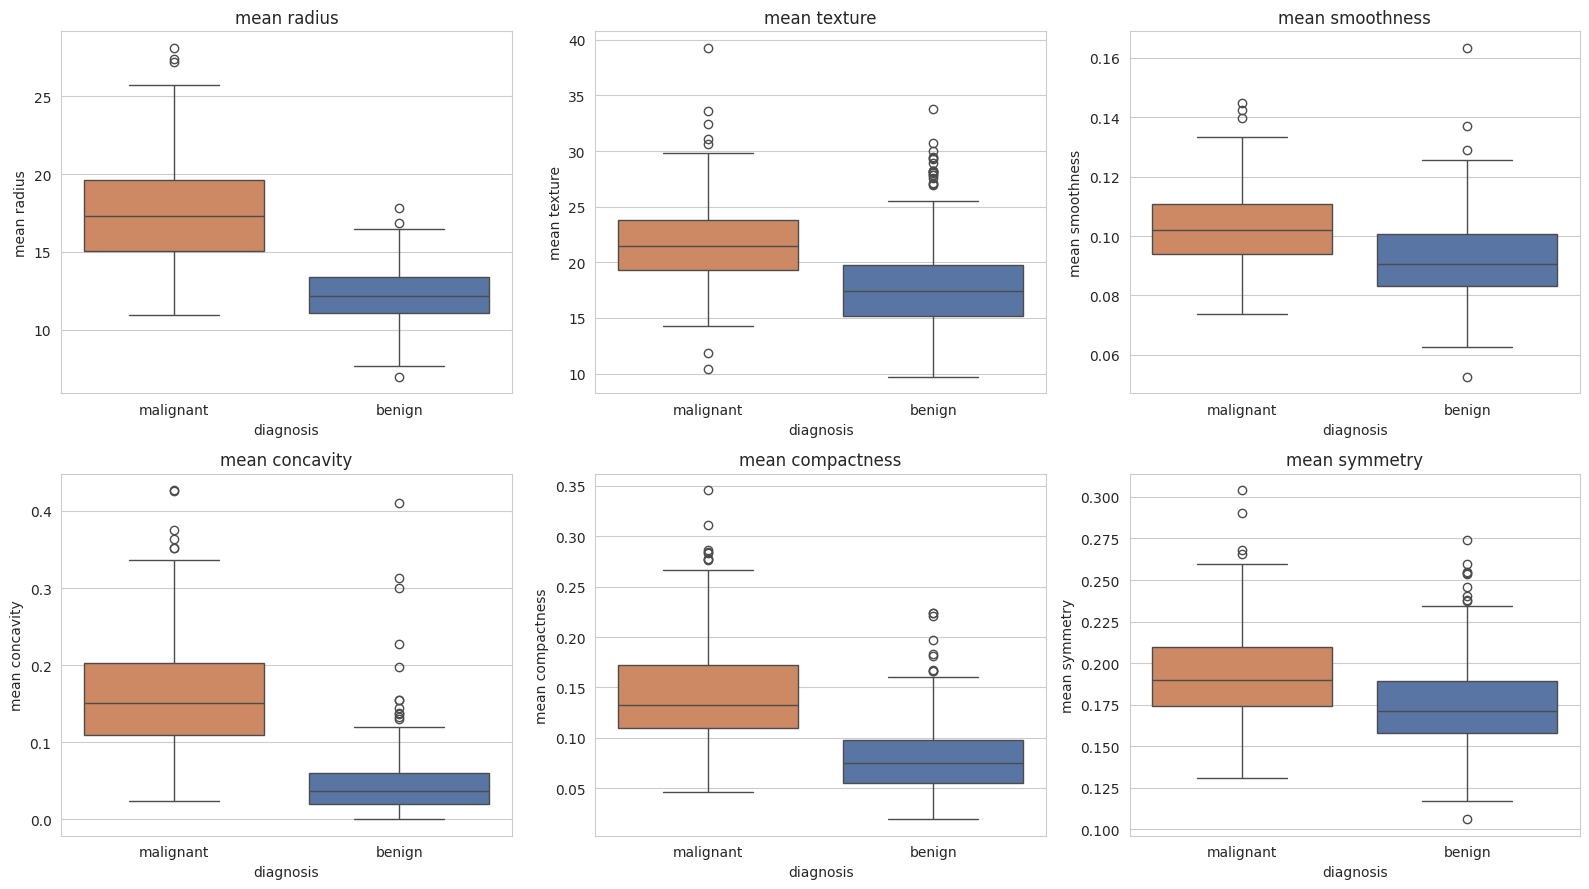

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=df, x='diagnosis', y=feat, ax=ax, palette=['#DD8452','#4C72B0'])
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=110)
plt.show()

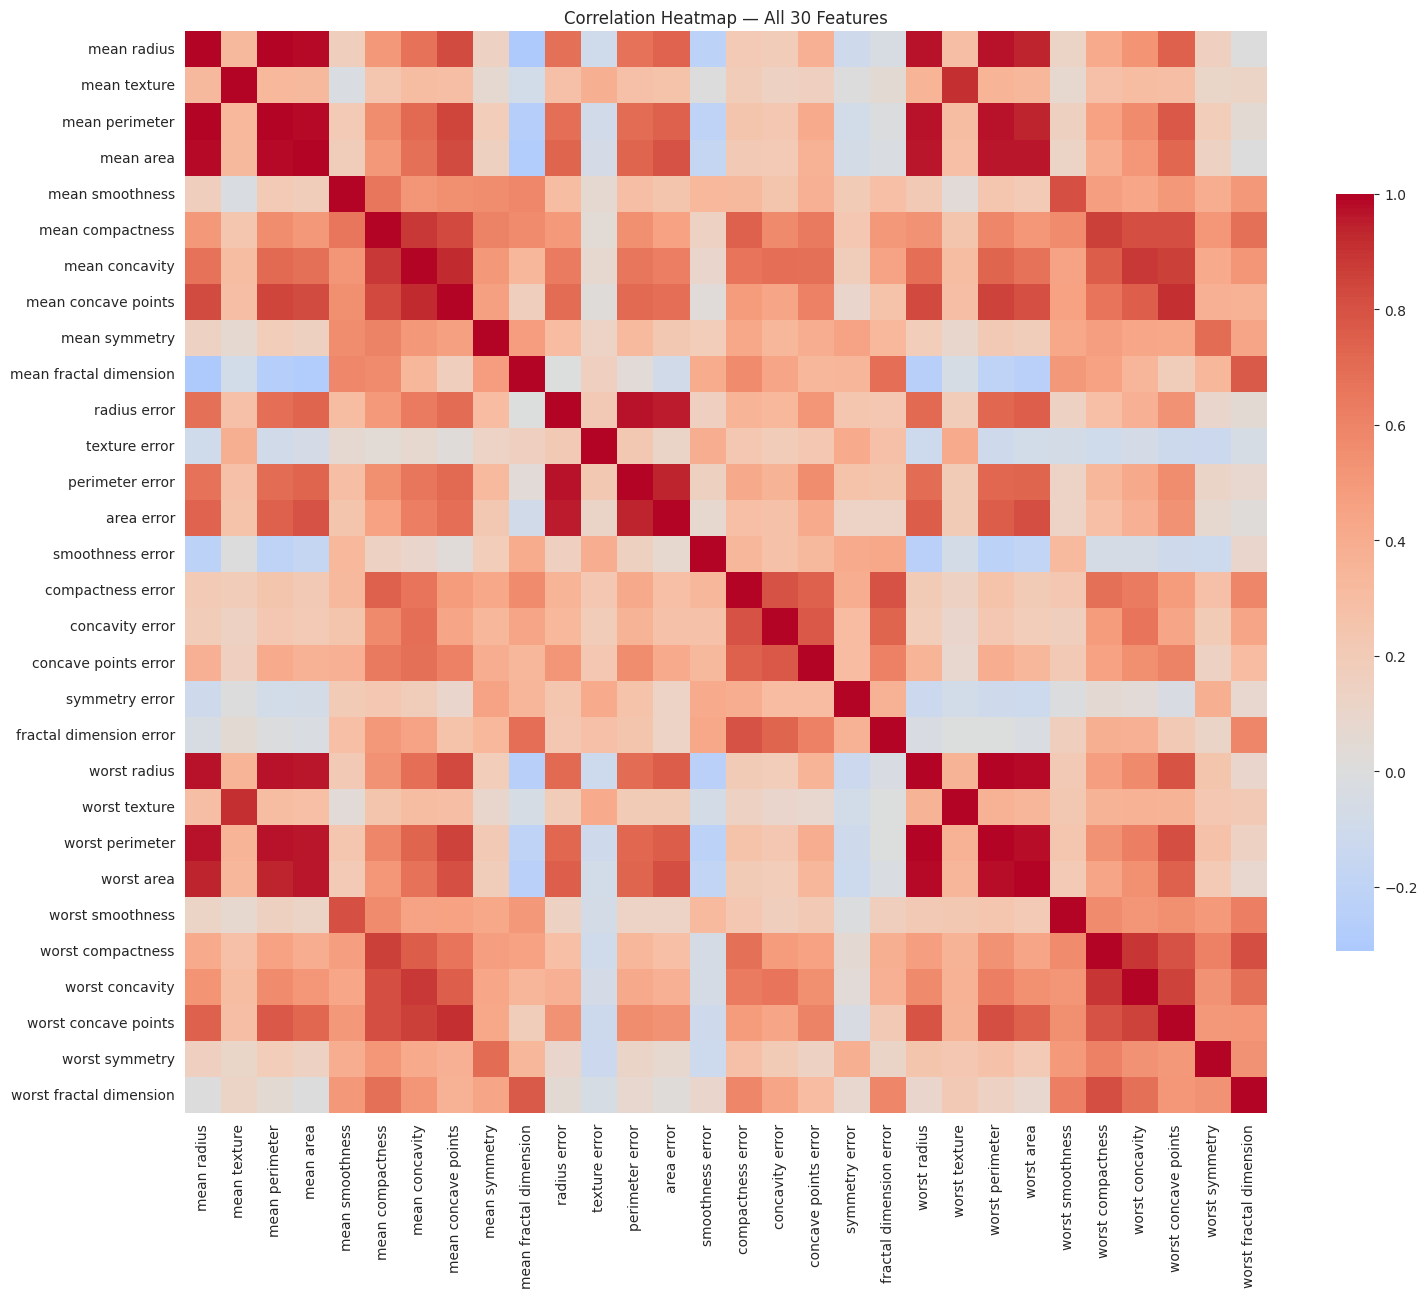

In [7]:
plt.figure(figsize=(16,13))
corr = df[data.feature_names].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.7})
plt.title('Correlation Heatmap — All 30 Features')
plt.tight_layout()
plt.savefig('eda_corr_heatmap.png', dpi=110)
plt.show()

/tmp/ipykernel_95/1691173919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diagnosis', palette=['#DD8452','#4C72B0'])


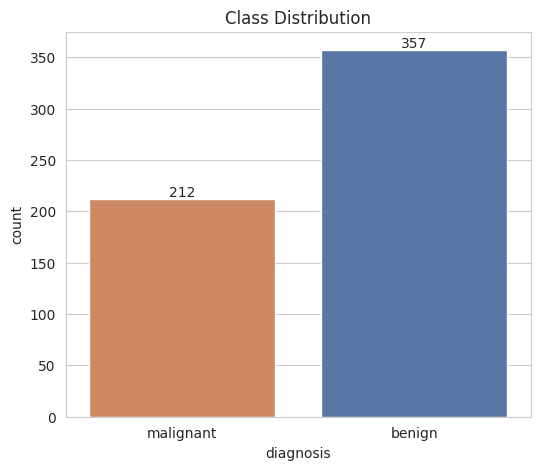

diagnosis
benign       357
malignant    212
Name: count, dtype: int64
diagnosis
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='diagnosis', palette=['#DD8452','#4C72B0'])
plt.title('Class Distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.savefig('eda_class_distribution.png', dpi=110)
plt.show()

print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True).round(3))

### 1.5 Class Imbalance Discussion

The class split is **benign 357 (62.7%) vs. malignant 212 (37.3%)** — moderately imbalanced (roughly 1.7:1), not severe, but not balanced either.

**Implications for model training in a medical diagnosis context:**
- A model can reach ~63% accuracy by trivially predicting "benign" for everyone, so **accuracy alone is a misleading metric** here.
- The clinically costly error is a **false negative** (calling a malignant tumor benign) — missing cancer has far worse consequences than a false positive (an unnecessary follow-up biopsy on a benign case). This means **recall on the malignant class** matters more than overall accuracy.
- Stratified train/test splitting (Task 2) is used specifically so the minority (malignant) class is proportionally represented in both sets, avoiding an evaluation set that under- or over-represents it by chance.

## Task 2: Data Preprocessing

### 2.1 Encode Target Variable
sklearn already encodes the target as binary: `0 = malignant`, `1 = benign`. For clarity in a diagnostic context we define `1 = malignant (positive/disease class)`, `0 = benign`, so that precision/recall for the "positive" class align with detecting cancer.

In [9]:
df['malignant_flag'] = (df['target'] == 0).astype(int)  # 1 = malignant, 0 = benign
X = df[data.feature_names]
y = df['malignant_flag']

print(y.value_counts())
print("1 = malignant (positive class), 0 = benign")

malignant_flag
0    357
1    212
Name: count, dtype: int64
1 = malignant (positive class), 0 = benign


### 2.2 Stratified Train/Test Split (80/20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (455, 30)  Test shape: (114, 30)

Train class balance:
 malignant_flag
0    0.626
1    0.374
Name: proportion, dtype: float64

Test class balance:
 malignant_flag
0    0.632
1    0.368
Name: proportion, dtype: float64


### 2.3 Feature Standardization

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Post-scaling train mean~0, std~1 check:",
      X_train_scaled.mean().round(3), X_train_scaled.std().round(3))
print("Test set transformed using TRAIN-fit scaler only (no data leakage).")

Post-scaling train mean~0, std~1 check: 0.0 1.0
Test set transformed using TRAIN-fit scaler only (no data leakage).


## Task 3: Model Training and Basic Evaluation

### 3.1 Train Logistic Regression

In [12]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of malignant

print("Model trained.")

Model trained.


### 3.2 Accuracy

In [13]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9649


### 3.3 Precision, Recall, F1-score (both classes)

In [14]:
print(classification_report(y_test, y_pred, target_names=['benign (0)', 'malignant (1)']))

               precision    recall  f1-score   support

   benign (0)       0.96      0.99      0.97        72
malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### 3.4 Confusion Matrix

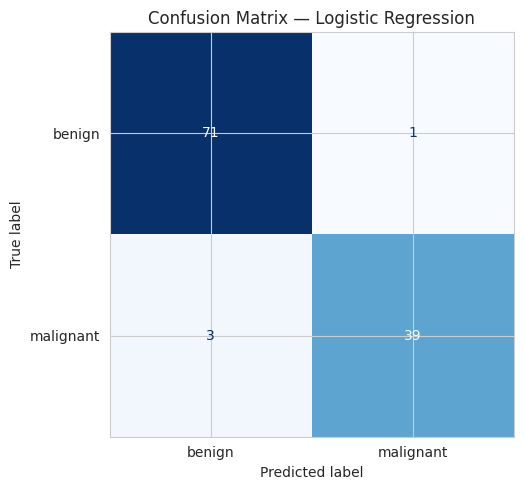

True Negatives (benign correctly identified): 71
False Positives (benign misclassified as malignant): 1
False Negatives (malignant MISSED — most costly error): 3
True Positives (malignant correctly identified): 39


In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign','malignant'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=110)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (benign correctly identified): {tn}")
print(f"False Positives (benign misclassified as malignant): {fp}")
print(f"False Negatives (malignant MISSED — most costly error): {fn}")
print(f"True Positives (malignant correctly identified): {tp}")

### 3.5 ROC Curve and AUC Score

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


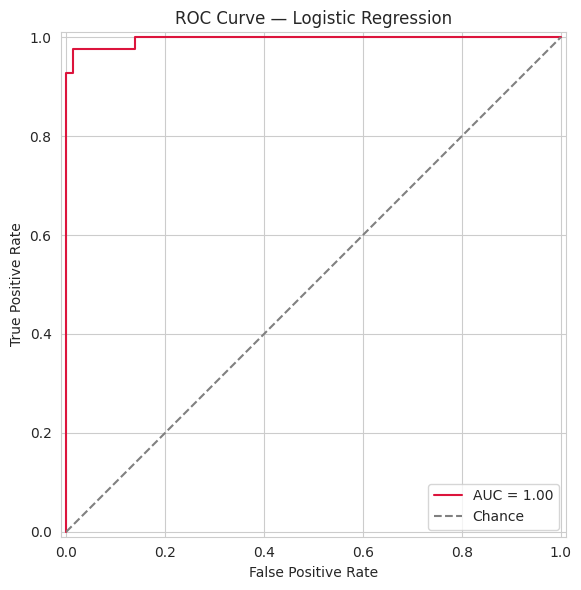

AUC Score: 0.9960


In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score).plot(ax=ax, color='crimson')
ax.plot([0,1], [0,1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=110)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

### 3.6 Interpretation

- **Accuracy** alone would be a misleading headline number given the class imbalance noted in Task 1 — it does not distinguish "safe" errors (false positives) from dangerous ones (false negatives).
- **Recall on the malignant class** is the single most clinically important number here: it answers *"of all patients who actually have cancer, what fraction did the model correctly flag?"* A high malignant-class recall is essential, since a missed diagnosis (false negative) can delay life-saving treatment, whereas a false positive typically just costs an extra confirmatory test.
- **Precision on the malignant class** matters too, but secondarily — low precision means unnecessary patient anxiety and follow-up procedures, which is undesirable but far less harmful than a missed cancer.
- **F1-score** balances the two and is a reasonable single-number summary per class, more trustworthy here than raw accuracy.
- The **confusion matrix** makes the false-negative count directly visible — the number a clinician/model-auditor should scrutinize first in this domain, more than overall accuracy.
- A **high AUC** shows the model separates the two classes well across all thresholds, which matters because in practice the decision threshold (default 0.5) can be tuned — e.g., lowered — to further reduce false negatives at the cost of more false positives, which is often the right trade-off in cancer screening.

**Takeaway:** for medical diagnosis tasks, evaluation should be read in order of **recall (malignant) → confusion matrix → F1 → AUC → accuracy**, not the reverse — accuracy is the least informative metric on an imbalanced diagnostic dataset like this one.